# Bibliotekos

In [26]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA

# Duomenų paruošimas

In [27]:
file_path = os.path.join("..", "1_laboratorinis", "loan_data.csv")
data = pd.read_csv(file_path)

cols_to_factor = ['credit.policy', 'not.fully.paid', 'purpose']
for col in cols_to_factor:
    data[col] = data[col].astype('category')

data['annual.inc'] = np.exp(data['log.annual.inc'])

print(f"Eilučių skaičius: {len(data)}")
print(f"Stulpelių skaičius: {len(data.columns)}")

Eilučių skaičius: 9578
Stulpelių skaičius: 15


In [28]:
sampled_data = data.groupby(['purpose', 'credit.policy'], observed=False).sample(
    frac=0.4, 
    random_state=6202
).reset_index(drop=True)

print(f"\nAtrinktų duomenų dydis: {len(sampled_data)}")


Atrinktų duomenų dydis: 3832


<span style="color: red;">Poaibio eiluciu sk nesutampa su R!!</span>

# Normavimas 

In [29]:
def min_max_normalization(x):
    return (x - x.min()) / (x.max() - x.min())

numeric_cols = sampled_data.select_dtypes(include=[np.number])
min_max_data = numeric_cols.apply(min_max_normalization)

categorical_cols = sampled_data.select_dtypes(exclude=[np.number])
full_min_max_data = pd.concat([min_max_data, categorical_cols], axis=1)

min_max_data.head()

,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,annual.inc
0,0.247206,0.072011,0.363843,0.088433,0.404762,0.252568,0.006169,0.901408,0.000000,0.0,0.0,0.015173
1,0.471400,0.264423,0.538387,0.034633,0.285714,0.199361,0.009275,0.413146,0.148148,0.0,0.0,0.049939
2,0.468113,0.183477,0.029933,0.504371,0.214286,0.000000,0.000000,0.448826,0.037037,0.0,0.0,0.000344
3,0.281394,0.108729,0.622255,0.336247,0.333333,0.218260,0.000000,0.203756,0.148148,0.0,0.0,0.086767
4,0.451677,0.356796,0.538661,0.187962,0.547619,0.408971,0.011692,0.646948,0.222222,0.0,0.0,0.050030


In [30]:
full_min_max_data.head()

,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,annual.inc,credit.policy,purpose,not.fully.paid
0,0.247206,0.072011,0.363843,0.088433,0.404762,0.252568,0.006169,0.901408,0.000000,0.0,0.0,0.015173,0,all_other,0
1,0.471400,0.264423,0.538387,0.034633,0.285714,0.199361,0.009275,0.413146,0.148148,0.0,0.0,0.049939,0,all_other,1
2,0.468113,0.183477,0.029933,0.504371,0.214286,0.000000,0.000000,0.448826,0.037037,0.0,0.0,0.000344,0,all_other,0
3,0.281394,0.108729,0.622255,0.336247,0.333333,0.218260,0.000000,0.203756,0.148148,0.0,0.0,0.086767,0,all_other,0
4,0.451677,0.356796,0.538661,0.187962,0.547619,0.408971,0.011692,0.646948,0.222222,0.0,0.0,0.050030,0,all_other,0


# PCA

In [31]:
def PCA_Algorithm(data_scaled, n_comp):
    pca = PCA(n_components = n_comp)
    data_pca = pca.fit_transform(data_scaled)
    return(data_pca, pca.explained_variance_ratio_)

In [32]:
PCA_transformed_data, PCA_variance_data = PCA_Algorithm(min_max_data, n_comp=2)
PCA_variance_data_proc = np.round(PCA_variance_data * 100, decimals = 1)

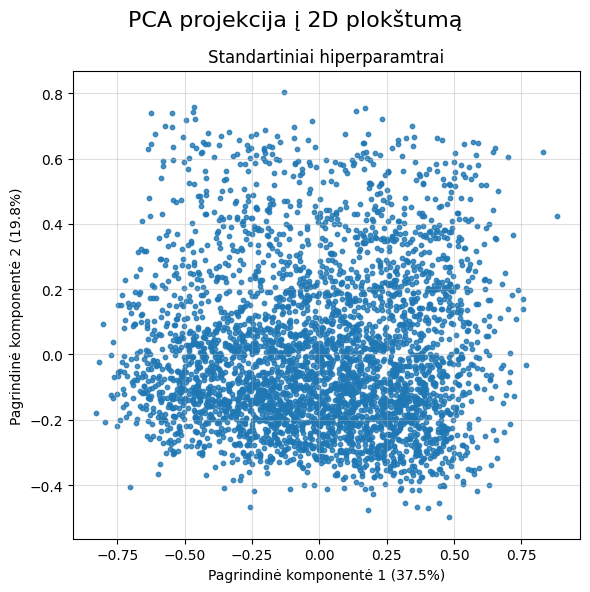

In [40]:
plt.figure(figsize=(6, 6))
plt.scatter(PCA_transformed_data[:, 0], PCA_transformed_data[:, 1], alpha=0.8, s=10)
plt.title("Standartiniai hiperparamtrai")
plt.xlabel(f"Pagrindinė komponentė 1 ({PCA_variance_data_proc[0]}%)")
plt.ylabel(f"Pagrindinė komponentė 2 ({PCA_variance_data_proc[1]}%)")
plt.grid(alpha=0.4)

plt.suptitle("PCA projekcija į 2D plokštumą", fontsize=16)
plt.tight_layout()
plt.show()

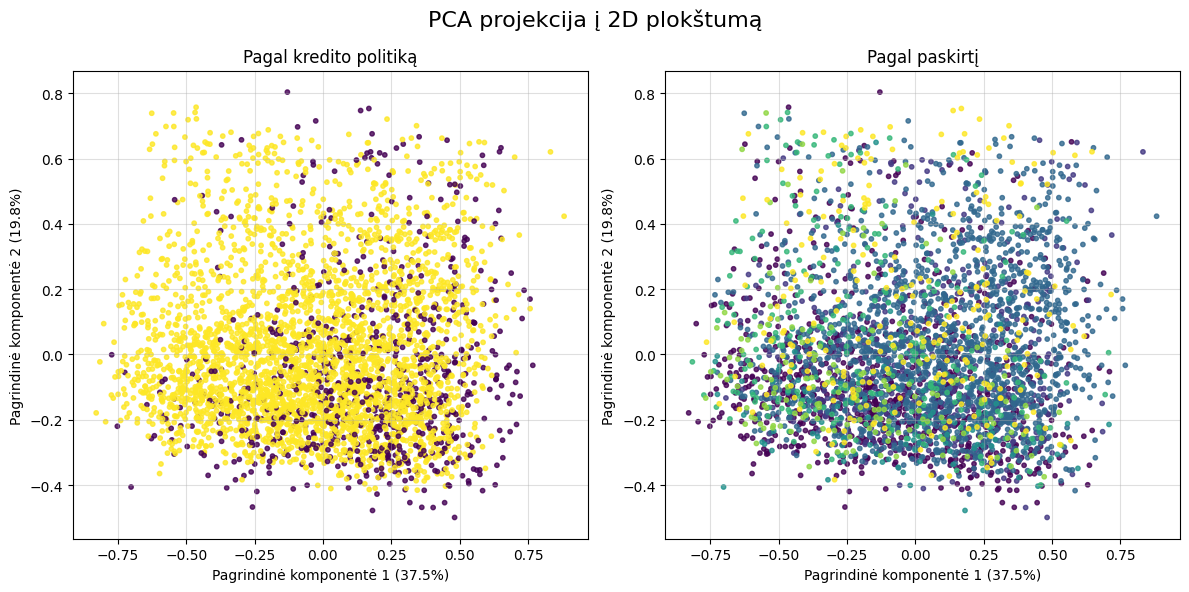

In [ ]:
credit_policy = full_min_max_data['credit.policy']
purpose_codes = full_min_max_data['purpose'].astype('category').cat.codes

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.scatter(PCA_transformed_data[:, 0], PCA_transformed_data[:, 1], alpha=0.8, s=10, c=credit_policy)
plt.title("Pagal kredito politiką")
plt.xlabel(f"Pagrindinė komponentė 1 ({PCA_variance_data_proc[0]}%)")
plt.ylabel(f"Pagrindinė komponentė 2 ({PCA_variance_data_proc[1]}%)")
plt.grid(alpha=0.4)

plt.subplot(1, 2, 2)
plt.scatter(PCA_transformed_data[:, 0], PCA_transformed_data[:, 1], alpha=0.8, s=10, c=purpose_codes)
plt.title("Pagal paskirtį")
plt.xlabel(f"Pagrindinė komponentė 1 ({PCA_variance_data_proc[0]}%)")
plt.ylabel(f"Pagrindinė komponentė 2 ({PCA_variance_data_proc[1]}%)")
plt.grid(alpha=0.4)

plt.suptitle("PCA projekcija į 2D plokštumą", fontsize=16)
plt.tight_layout()
plt.show()